## Cosmetic Shop: Time to Next Purchase 

Setup and Load

In [246]:
import duckdb 
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
conn = duckdb.connect()

PARQUET_PATH = Path("../data/processed/master_events.parquet").as_posix()
PURCHASE_PATH = Path("../data/processed/purchases.parquet").as_posix()


In [247]:
df = pd.read_parquet(PURCHASE_PATH)
df

,event_time,product_id,category_id,category_code,brand,price,is_refund,user_id,user_session
0,2019-10-01 00:06:35,5814822,1487580005897601916,NaN,runail,2.38,0,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe
1,2019-10-01 00:06:35,5875317,2029082628195353599,NaN,NaN,1.59,0,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe
2,2019-10-01 00:06:35,5619862,1487580006895846315,NaN,runail,5.32,0,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe
3,2019-10-01 00:06:35,5619866,1487580006895846315,NaN,runail,2.86,0,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe
4,2019-10-01 00:06:35,5696184,1487580005134238553,NaN,runail,2.38,0,474232307,445f2b74-5e4c-427e-b7fa-6e0a28b156fe
...,...,...,...,...,...,...,...,...,...
1287002,2020-02-29 23:46:01,5742957,1487580009387261981,NaN,NaN,3.81,0,620865261,64389dba-26c4-f328-6972-166a48654eaa
1287003,2020-02-29 23:54:44,5929649,1487580006350586771,appliances.environment.vacuum,max,95.08,0,548866558,199869f5-3a22-4a47-8678-7c343d09bb8e
1287004,2020-02-29 23:54:44,5692863,1487580007910867929,NaN,yoko,7.83,0,548866558,199869f5-3a22-4a47-8678-7c343d09bb8e
1287005,2020-02-29 23:54:44,5802432,1487580009286598681,NaN,NaN,0.32,0,548866558,199869f5-3a22-4a47-8678-7c343d09bb8e


In [248]:
query = f""" 
    SELECT 
        user_id,
        user_session,
        MIN(event_time) AS occasion_time,
        MAX(CAST(is_refund AS INTEGER)) AS has_refund,
        COUNT(*) AS n_items
    FROM '{PURCHASE_PATH}'
    GROUP BY user_session, user_id
    ORDER BY user_id, occasion_time
"""

occasions = conn.execute(query).df()
occasions

,user_id,user_session,occasion_time,has_refund,n_items
0,9794320,30d70cc3-86ee-4b5d-879c-40f06132163c,2019-11-25 05:07:13,0,4
1,10079204,f873d16b-4efa-4e92-81be-92948aef2ff5,2019-11-06 10:43:30,0,2
2,10280338,bcc9bfa0-8a71-485d-b315-297b0038b4c2,2019-11-20 18:36:14,0,10
3,10280338,bce6164d-93ef-4d65-ae2f-7ee15552eae7,2019-11-21 11:31:09,0,6
4,10280338,c9cad2fe-9213-42c0-a68a-c329b62f394a,2020-01-12 22:54:37,0,1
...,...,...,...,...,...
155612,622065819,a6c280be-ad01-413d-818e-a818f3ac3558,2020-02-29 22:29:19,0,4
155613,622066161,389680bd-69c6-4364-b549-651f82f8ffce,2020-02-29 21:54:22,0,4
155614,622067983,93a3b8e4-f726-4cdc-8d18-12d4c6f23b59,2020-02-29 22:33:37,0,10
155615,622069477,8d85bde1-9586-4a39-a8ed-ecc59ea083a0,2020-02-29 22:05:30,0,1


In [249]:
occasions['next_occasion_time'] = (
    occasions.groupby('user_id')['occasion_time'].shift(-1)
)
occasions['days_to_next_purchase'] = round((
    occasions['next_occasion_time'] - occasions['occasion_time']
    ).dt.total_seconds() / 86400,4)

occasions

,user_id,user_session,occasion_time,has_refund,n_items,next_occasion_time,days_to_next_purchase
0,9794320,30d70cc3-86ee-4b5d-879c-40f06132163c,2019-11-25 05:07:13,0,4,NaT,NaN
1,10079204,f873d16b-4efa-4e92-81be-92948aef2ff5,2019-11-06 10:43:30,0,2,NaT,NaN
2,10280338,bcc9bfa0-8a71-485d-b315-297b0038b4c2,2019-11-20 18:36:14,0,10,2019-11-21 11:31:09,0.7048
3,10280338,bce6164d-93ef-4d65-ae2f-7ee15552eae7,2019-11-21 11:31:09,0,6,2020-01-12 22:54:37,52.4746
4,10280338,c9cad2fe-9213-42c0-a68a-c329b62f394a,2020-01-12 22:54:37,0,1,2020-02-13 21:25:18,31.9380
...,...,...,...,...,...,...,...
155612,622065819,a6c280be-ad01-413d-818e-a818f3ac3558,2020-02-29 22:29:19,0,4,NaT,NaN
155613,622066161,389680bd-69c6-4364-b549-651f82f8ffce,2020-02-29 21:54:22,0,4,NaT,NaN
155614,622067983,93a3b8e4-f726-4cdc-8d18-12d4c6f23b59,2020-02-29 22:33:37,0,10,NaT,NaN
155615,622069477,8d85bde1-9586-4a39-a8ed-ecc59ea083a0,2020-02-29 22:05:30,0,1,NaT,NaN


In [250]:
dataset_end = purchases['event_time'].max()

occasions['censored'] = occasions['next_occasion_time'].isna().astype(int)

occasions['duration_days'] = np.where(
    occasions['censored'] == 1,
    (dataset_end - occasions['occasion_time']).dt.total_seconds() / 86400,
    occasions['days_to_next_purchase'],
)
occasions

,user_id,user_session,occasion_time,has_refund,n_items,next_occasion_time,days_to_next_purchase,censored,duration_days
0,9794320,30d70cc3-86ee-4b5d-879c-40f06132163c,2019-11-25 05:07:13,0,4,NaT,NaN,1,96.782998
1,10079204,f873d16b-4efa-4e92-81be-92948aef2ff5,2019-11-06 10:43:30,0,2,NaT,NaN,1,115.549468
2,10280338,bcc9bfa0-8a71-485d-b315-297b0038b4c2,2019-11-20 18:36:14,0,10,2019-11-21 11:31:09,0.7048,0,0.704800
3,10280338,bce6164d-93ef-4d65-ae2f-7ee15552eae7,2019-11-21 11:31:09,0,6,2020-01-12 22:54:37,52.4746,0,52.474600
4,10280338,c9cad2fe-9213-42c0-a68a-c329b62f394a,2020-01-12 22:54:37,0,1,2020-02-13 21:25:18,31.9380,0,31.938000
...,...,...,...,...,...,...,...,...,...
155612,622065819,a6c280be-ad01-413d-818e-a818f3ac3558,2020-02-29 22:29:19,0,4,NaT,NaN,1,0.059317
155613,622066161,389680bd-69c6-4364-b549-651f82f8ffce,2020-02-29 21:54:22,0,4,NaT,NaN,1,0.083588
155614,622067983,93a3b8e4-f726-4cdc-8d18-12d4c6f23b59,2020-02-29 22:33:37,0,10,NaT,NaN,1,0.056331
155615,622069477,8d85bde1-9586-4a39-a8ed-ecc59ea083a0,2020-02-29 22:05:30,0,1,NaT,NaN,1,0.075856


In [251]:
survival_input = occasions[
    ['user_id', 'user_session', 'occasion_time', 'n_items', 'has_refund', 'duration_days', 'censored']
].copy()

print(f"Total occasions: {len(survival_input):,}")
print(f"Censored: {survival_input['censored'].sum():,} ({survival_input['censored'].mean():.1%})")
print(f"Observed repurchases: {(survival_input['censored'] == 0).sum():,}")

survival_input.head(10)

Total occasions: 155,617
Censored: 110,518 (71.0%)
Observed repurchases: 45,099


,user_id,user_session,occasion_time,n_items,has_refund,duration_days,censored
0,9794320,30d70cc3-86ee-4b5d-879c-40f06132163c,2019-11-25 05:07:13,4,0,96.782998,1
1,10079204,f873d16b-4efa-4e92-81be-92948aef2ff5,2019-11-06 10:43:30,2,0,115.549468,1
2,10280338,bcc9bfa0-8a71-485d-b315-297b0038b4c2,2019-11-20 18:36:14,10,0,0.704800,0
3,10280338,bce6164d-93ef-4d65-ae2f-7ee15552eae7,2019-11-21 11:31:09,6,0,52.474600,0
4,10280338,c9cad2fe-9213-42c0-a68a-c329b62f394a,2020-01-12 22:54:37,1,0,31.938000,0
5,10280338,5a8ef64a-9215-4c88-ad5f-b3bab4e03fb3,2020-02-13 21:25:18,47,0,5.747400,0
6,10280338,9728269f-2014-4d85-a95a-0dab99c4851e,2020-02-19 15:21:31,22,0,10.356400,1
7,12055855,98b129c4-2ab1-4e89-8511-de4bf7f0d943,2019-12-20 12:05:29,4,0,71.492535,1
8,12936739,f0f01819-3cf4-455c-a6e5-61d25867f9ea,2020-01-17 07:51:19,2,0,43.669039,1
9,15400971,77f879cf-e087-4ef5-a0dd-36620a6d61a3,2019-12-13 12:32:31,3,0,78.473762,1


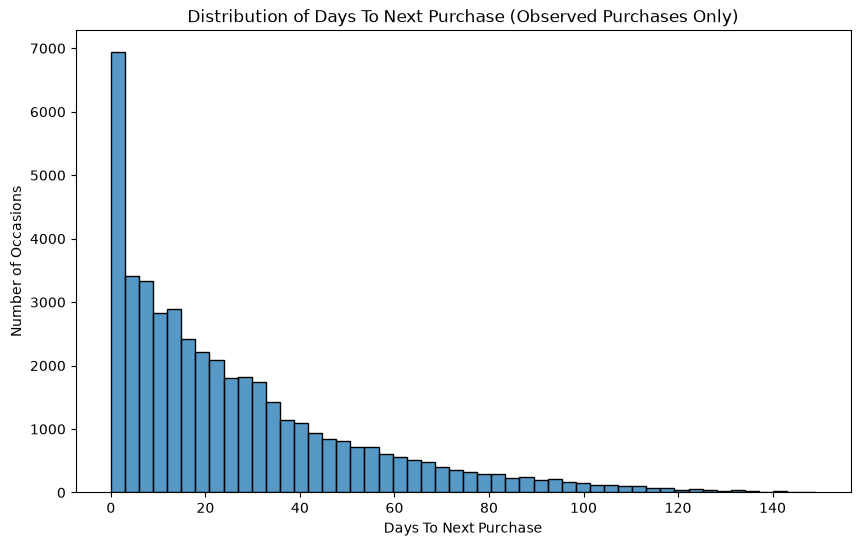

Median time to repurchase: 18.9 days

Additional Information:


count    45099.000000
mean        26.542439
std         26.071831
min          0.000000
25%          6.806500
50%         18.921500
75%         37.975000
max        149.059700
Name: duration_days, dtype: float64

In [252]:
uncensored = survival_input[survival_input['censored'] == 0]
plt.figure(figsize=(10,6))

sns.histplot(
    data = uncensored,
    x = 'duration_days',
    bins = 50
)

plt.title("Distribution of Days To Next Purchase (Observed Purchases Only)")
plt.xlabel("Days To Next Purchase")
plt.ylabel("Number of Occasions")

plt.show()

median_days = uncensored['duration_days'].median()
print(f"Median time to repurchase: {median_days:.1f} days")

print(f"\nAdditional Information:")
uncensored['duration_days'].describe()

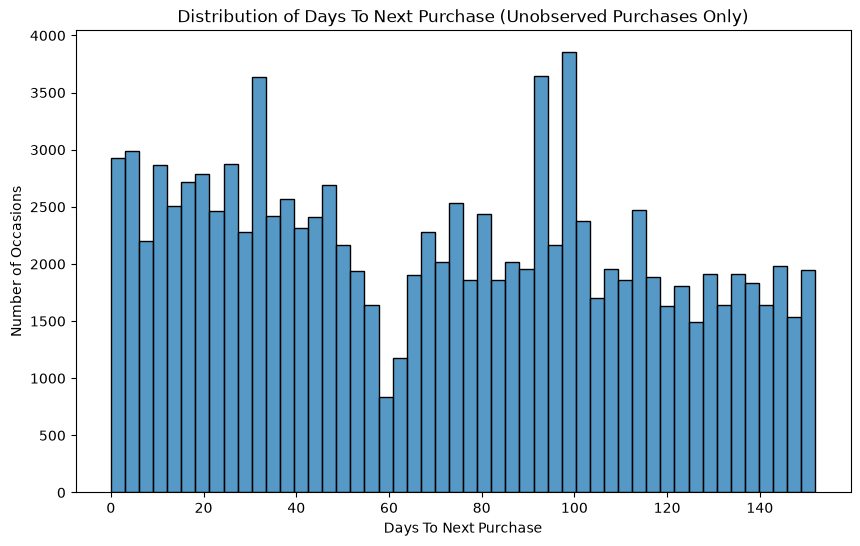

Median time Until Final Date in Data: 71.2 days

Additional Information:


count    110518.000000
mean         70.525855
std          43.965880
min           0.000000
25%          31.603015
50%          71.160052
75%         106.189063
max         151.989051
Name: duration_days, dtype: float64

In [253]:
censored = survival_input[survival_input['censored'] == 1]

plt.figure(figsize=(10,6))

sns.histplot(
    data = censored,
    x = 'duration_days',
    bins = 50
)

plt.title("Distribution of Days To Next Purchase (Unobserved Purchases Only)")
plt.xlabel("Days To Next Purchase")
plt.ylabel("Number of Occasions")

plt.show()


median_days = censored['duration_days'].median()
print(f"Median time Until Final Date in Data: {median_days:.1f} days")

print(f"\nAdditional Information:")
censored['duration_days'].describe()

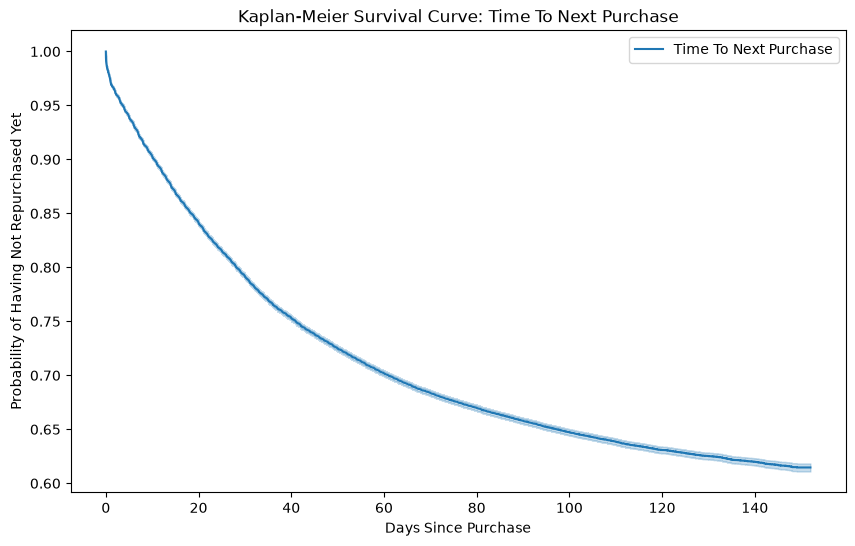

Median time to repurchase: inf days
By day  7: 7.6% of customers had repurchased
By day 14: 12.4% of customers had repurchased
By day 30: 20.8% of customers had repurchased
By day 60: 29.8% of customers had repurchased
By day 90: 34.2% of customers had repurchased


In [254]:
kmf = KaplanMeierFitter()
kmf.fit(
    durations = survival_input['duration_days'],
    event_observed = 1 - survival_input['censored'],
    label = 'Time To Next Purchase'
)

plt.figure(figsize=(10,6))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve: Time To Next Purchase')
plt.xlabel('Days Since Purchase')
plt.ylabel('Probability of Having Not Repurchased Yet')
plt.show()

median_days = kmf.median_survival_time_
print(f"Median time to repurchase: {median_days:.1f} days")

for days in [7, 14, 30, 60, 90]:
    prob_not_repurchased = kmf.survival_function_at_times(days).values[0]
    print(f"By day{days:>3}: {1 - prob_not_repurchased:.1%} of customers had repurchased")

In [258]:
total_occasions = len(survival_input)
observed = (survival_input['censored'] == 0).sum()
censored = (survival_input['censored'] == 1).sum()

print(f"Total occasions: {total_occasions:,}")
print(f"Observed repurchases: {observed:,} ({observed/total_occasions:.1%})")
print(f"Censored: {censored:,} ({censored/total_occasions:.1%})")

Total occasions: 155,617
Observed repurchases: 45,099 (29.0%)
Censored: 110,518 (71.0%)


# Findings:

Across 155,617 purchases, there are 45,099 (29.0%) observed repurchases, with 110,518 (71.0%) single purchases by customers. 

Those 71.0% mean that we simply don't know when they will repurchase, not that they will will not.

Our 5-month dataset is limited; a clear sign of this is the infinite median of the time-to-repurchase median curve. The survival curve never crosses 50%, showing that repurchase activity takes longer to monitor than the 5-month window in this dataset. 

Our approach of using only uncensored data in a histogram (ignoring 71% of data) yielded a median of 18.9 days and a mean of 26.5 days, values that are biased low due to only reflecting customers that repurchased in a short 5-month window and eliminating slower repurchasers.

# What This Means

Most customers do not repurchase in a 5-month window

The distribution of customers who repurchased is right-skewed, concentrated in the first 20 days

# Limitations

71% censoring means that the tail of the survival curve is based on comparatively little data

Right censoring is structural and not due to data quality. It is a consequence of only having 5 months of data


# Next Steps

If a longer window of data becomes available, it is worth re-running these tests to see how the 71% censored results shift.

Segment re-purchase timing by category, price tier, or first-vs-repeat customer to see if the low observed repurchase rate 